In [4]:
import pandas as pd
import numpy as np
import wquantiles as wq # weighted-median
import os
import multiprocessing as mp


In [3]:
import wquantiles as wq 

# ... inside your wtArmMedianOne function ...
dat = np.array([1,2,3,3,3,3,4,6,3,3,3])
# Ensure you also define 'w' (weights) here for the function to work
w = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

# Corrected line: Use wq.median() instead of wq.weighted_median()
m = wq.median(dat, w)

In [4]:


dirpath = "/stomics_data/liminData/Visium/stmut_python/two_steps_out/cluster_summary"
dir1 = "/stomics_data/liminData/Visium/stmut_python"
graph_based_csv = f"{dir1}/BD17_bin8_inputs/Graph-Based.csv"


In [31]:
# Grouped-spots summary
dir1 = "/stomics_data/liminData/Visium/stmut_python"
dirpath = f"{dir1}/two_steps_out/cluster_summary"
files = os.listdir(dirpath)
f1 = f"{dirpath}/{files[0]}"
#print(f1)
df = pd.read_csv(f1)
#merged_df = df[['main_barcode','total_non_zero','array_row','array_col']]
merged_df = df
n = merged_df.shape[0]
for f in files[1:]:
    #print(f)
    fpath = f"{dir1}/two_steps_out/cluster_summary/{f}"
    df = pd.read_csv(fpath)
    #df1 = df[['main_barcode','total_non_zero','array_row','array_col']]
    df1 = df
    i = df1.shape[0]
    n = n+1
    merged_df = pd.concat([merged_df, df1], ignore_index=True)

merged_df['merged_barcodes_count'] = merged_df['merged_barcodes'].str.split(',').str.len().fillna(0).astype(int)
merged_df['log_barcode_count'] = np.log1p(merged_df['merged_barcodes_count'])

merged_df


,group_id,main_barcode,total_non_zero,array_col,array_row,merged_barcodes,merged_barcodes_count,log_barcode_count
0,group_1,s_008um_00149_00029-1,3029,29,149,"s_008um_00149_00029-1,s_008um_00153_00034-1,s_...",26,3.295837
1,group_2,s_008um_00571_00000-1,3002,0,571,"s_008um_00571_00000-1,s_008um_00571_00001-1,s_...",20,3.044522
2,group_3,s_008um_00577_00006-1,3054,6,577,"s_008um_00577_00006-1,s_008um_00577_00007-1,s_...",17,2.890372
3,group_4,s_008um_00583_00008-1,3099,8,583,"s_008um_00583_00008-1,s_008um_00583_00009-1,s_...",17,2.890372
4,group_5,s_008um_00586_00013-1,3091,13,586,"s_008um_00586_00013-1,s_008um_00587_00013-1,s_...",16,2.833213
...,...,...,...,...,...,...,...,...
29783,group_22,s_008um_00729_00100-1,3003,100,729,"s_008um_00729_00100-1,s_008um_00730_00100-1,s_...",20,3.044522
29784,group_23,s_008um_00731_00092-1,3004,92,731,"s_008um_00731_00092-1,s_008um_00731_00093-1,s_...",24,3.218876
29785,group_24,s_008um_00733_00103-1,3079,103,733,"s_008um_00733_00103-1,s_008um_00734_00102-1,s_...",24,3.218876
29786,group_25,s_008um_00737_00114-1,3054,114,737,"s_008um_00737_00114-1,s_008um_00738_00114-1,s_...",20,3.044522


In [29]:
max(merged_df['merged_barcodes_count'].values)
min(merged_df['merged_barcodes_count'].values)
merged_df['merged_barcodes_count'].values.mean()

np.float64(22.734557539948973)

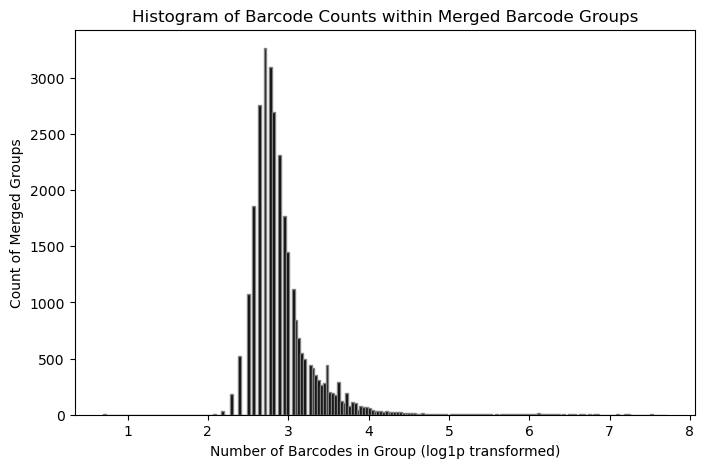

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# (Assuming you have run the previous code to add the 'barcode_count' column to merged_df)

plt.figure(figsize=(8, 5))

# Create the histogram
plt.hist(
    merged_df['log_barcode_count'], 
    bins=200, 
    color='black', 
    edgecolor='grey')

# Add labels and a title
plt.title("Histogram of Barcode Counts within Merged Barcode Groups")
plt.xlabel("Number of Barcodes in Group (log1p transformed)")
plt.ylabel("Count of Merged Groups")
plt.grid(False)

plt.savefig(f"{output_dir}/figures/barcodes_counts_histogram", dpi=500, bbox_inches='tight')
# Display the plot
plt.show()


# # Boxplot
# plt.figure(figsize=(6, 5))

# # Plot the boxplot directly from the DataFrame column
# merged_df.boxplot(column=['log_barcode_count'])

# # Add labels and a title
# plt.title("Boxplot of Barcode Counts")
# plt.ylabel("Number of Barcodes")
# plt.suptitle("") # Suppress the default pandas title
# plt.grid(False) # Turn off the grid for a cleaner boxplot

# plt.show()


In [2]:
# Grouped-spots summary
dir1 = "/stomics_data/liminData/Visium/stmut_python"
dirpath = f"{dir1}/two_steps_out/cluster_summary"
files = os.listdir(dirpath)
f1 = f"{dirpath}/{files[0]}"
#print(f1)
df = pd.read_csv(f1)
merged_df = df[['main_barcode','total_non_zero','array_row','array_col']]
n = merged_df.shape[0]
for f in files[1:]:
    #print(f)
    fpath = f"{dir1}/two_steps_out/cluster_summary/{f}"
    df = pd.read_csv(fpath)
    df1 = df[['main_barcode','total_non_zero','array_row','array_col']]
    i = df1.shape[0]
    n = n+1
    merged_df = pd.concat([merged_df, df1], ignore_index=True)

# merged spatial location
f1 = f"{dir1}/BD17_bin8_inputs/Graph-Based.csv"
dat1 = pd.read_csv(f1)

dat = pd.merge(merged_df, dat1, left_on='main_barcode', right_on='Barcode')
dat2 = dat[['main_barcode','Graph-based','Barcode','total_non_zero','array_row','array_col']]
dat2.rename(columns={'main_barcode':'barcode',
                     'Graph-based':'cluster',
                     'Barcode':'spot',
                     'total_non_zero':'TotalRDs'}, inplace = True)
dat2['barcode'] = dat2['barcode'].str.replace('-1', '.1')
dat2['spot'] = dat2['spot'].str.replace('-1', '.1')
#dat2.to_csv(f"{dir1}/two_steps_out/tempdir/grouped_spotSummary.csv", index=False)


In [50]:
# htp <- cnvPlot3(c7 = c7, ncluster = ncluster,method1=method1, method2 = method2, ...) # sort by clusters
import sys
import os
new_path = "/stomics_data/liminData/Visium/stmut_python/stmut-hires/python/"
sys.path.insert(0, new_path)

from call_cnv.barcodes_summary import ClusterSummary
from call_cnv.cluster_annotate import LoadAnnotate
from call_cnv.annotate_barcode import IntegrateAnnotate
from call_cnv.load_cdt import Loadcdt
from call_cnv.infer_cnv import InferCNV
from call_cnv.save_cnv import CNVWriter
from visualization.chromosome_meta import SortedChrom



dir1 = "/stomics_data/liminData/Visium/stmut_python"
output_dir = f"{dir1}/two_steps_out/"
graph_based_csv = f"{dir1}/BD17_bin8_inputs/Graph-Based.csv"
annotate_csv = f"{dir1}/BD17_bin8_inputs/annotate.csv"
print(f"graph_based_csv: {graph_based_csv}")

dirpath = os.path.join(output_dir,"cluster_summary")
cdt_file = os.path.join(output_dir, "cdt/grpWt.cdt")

"""Call cnv from cdt file"""
# Summarize grouped barcodes info
clustersum = ClusterSummary(dirpath,graph_based_csv)
merged_df = clustersum.merge_cluster_summary()
merged_barcode_summary = clustersum.cluster_summary()
annotate = LoadAnnotate.load_annotate(annotate_csv)       
annotatedbarcodes = IntegrateAnnotate(annotate,merged_barcode_summary)
annotated_barcode = annotatedbarcodes.annotate_barcode()

# Load cdt file.
cdt_matrix, cdt_meta = Loadcdt.cdt_loader(cdt_file)

# normalize cdt and call cnv
cdt = InferCNV(cdt_matrix,annotated_barcode)
c4_nontumor_normalize = cdt.cdt_processor() # same as c6 in R
# sort cnv first by cluster then by total reads
cdt_sortedby_cluster_totalreads = InferCNV.sort_cluster_totalreads(annotated_barcode,c4_nontumor_normalize)

# clusterSortedcnv is the same as CNVPlot2 cdt7
clusterSortedcnv = CNVWriter.save_cluster_sorted_cnv(cdt_sortedby_cluster_totalreads, cdt_meta, output_dir)
chr_meta = SortedChrom.gene_count_per_chr(cdt_meta)




graph_based_csv: /stomics_data/liminData/Visium/stmut_python/BD17_bin8_inputs/Graph-Based.csv


NameError: name 'self' is not defined

In [ ]:
# QQ plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import importlib

import call_cnv.cnvscore_orchestrators as cnvscore_orchestrators
importlib.reload(cnvscore_orchestrators)
import visualization.analysis_plots as analysis_plots
importlib.reload(analysis_plots)

from visualization.analysis_plots import AnalysisVisualizer
from call_cnv.cnvscore_orchestrators import CNVSortedByBulkCNV
from call_cnv.barcode_quintile import AssignBarcodeQuintile



output_dir = "/stomics_data/liminData/Visium/stmut_python/two_steps_out/"
bulk_csv = f"{output_dir}/tables/bulkCNV.csv"
pmtimes = 5

cnvSortedBulk = CNVSortedByBulkCNV(bulk_csv, pmtimes, output_dir, clusterSortedcnv)
permuts_long, caseCNVscore_FDR = cnvSortedBulk.run_pipeline()    

# QQ plot
visualizer = AnalysisVisualizer(permuts_long, caseCNVscore_FDR, pmtimes, output_dir)
data = visualizer.qq_data()
visualizer.cnv_score_qq_plot(data)
# cnvscore histogram
visualizer.plot_cnvscore_histogram()  

# Merged Barcode histogram
visualizer.plot_barcode_histogram(merged_df)

# Generate quintile data
all_combined=AssignBarcodeQuintile.barcode_quintils(merged_df,caseCNVscore_FDR)
AssignBarcodeQuintile.save_qt(all_combined, output_dir)

In [52]:

# #return c4_nontumor_normalize # c6 in R for other functions
# # c5 is the final matrix used to run CNVplot2 - sort by clusters and total reads
# # c5 same as c7 in R
# clusterSortedcnv # c7 in cnvPlot3
# CNVPlot2
 # same as c6 in R

 # CNVPlot1 - clusterSortedcnv = cdt



In [29]:
arm =["1p", "3p", "3q", "4q", "5q", "8q", "9q", "10p", "10q", "11q", "13p", "13q",
"20p", "20q", "21q", "14q", "17q"]
gainloss=[1, -1, 1, -1, -1, 1, 1, -1, -1, 1, -1, -1, 1, 1, -1, 1, 1]
bulk = pd.DataFrame({
    'arms':arm,
    'gainloss':gainloss
})
bulk.to_csv(f"{output_dir}/tables/bulkCNV.csv", index=False)

In [35]:
# This takes forever, bad design, Big O is ......
# caseCNVscore, permuts_long

# 1. Initialize new columns in caseCNVscore
caseCNVscore['Fraction_at_this_scor_or_higher_permut'] = 0
caseCNVscore['Fraction_at_that_scor_or_lower_permut'] = 0
caseCNVscore['Fraction_at_this_diff_or_higher_permut'] = 0

for v in range(total_n):
    current_cnv_score = caseCNVscore.iloc[v]['CNVScore']

    # Iterate permut data to find the first row that meets the condition.
    for i in range(nr):
        if permuts_long.iloc[i]['permutScore'] < current_cnv_score:
            caseCNVscore.at[v, 'Fraction_at_this_scor_or_higher_permut'] = permuts_long.at[i,'Fraction_at_this_scor_or_higher_permut']
            caseCNVscore.at[v, 'Fraction_at_that_scor_or_lower_permut'] = permuts_long.at[i, 'Fraction_at_that_scor_or_lower_permut']
            caseCNVscore.at[v, 'Fraction_at_this_diff_or_higher_permut'] = permuts_long.at[i, 'Fraction_at_this_diff_or_higher_permut']
            break

print(caseCNVscore.head())


/tmp/ipykernel_91464/44388253.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.967492949996561' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  caseCNVscore.at[v, 'Fraction_at_this_scor_or_higher_permut'] = permuts_long.at[i,'Fraction_at_this_scor_or_higher_permut']
/tmp/ipykernel_91464/44388253.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.03250739390604581' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  caseCNVscore.at[v, 'Fraction_at_that_scor_or_lower_permut'] = permuts_long.at[i, 'Fraction_at_that_scor_or_lower_permut']
/tmp/ipykernel_91464/44388253.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.039588348579682235' has dtype incompa

In [ ]:
# Allow auto-reload module instead of restart the kernal
%load_ext autoreload
%autoreload 2


Saved figure to CNVs_clustered_heatmap_with_dendrogram_and_chrbar.pdf


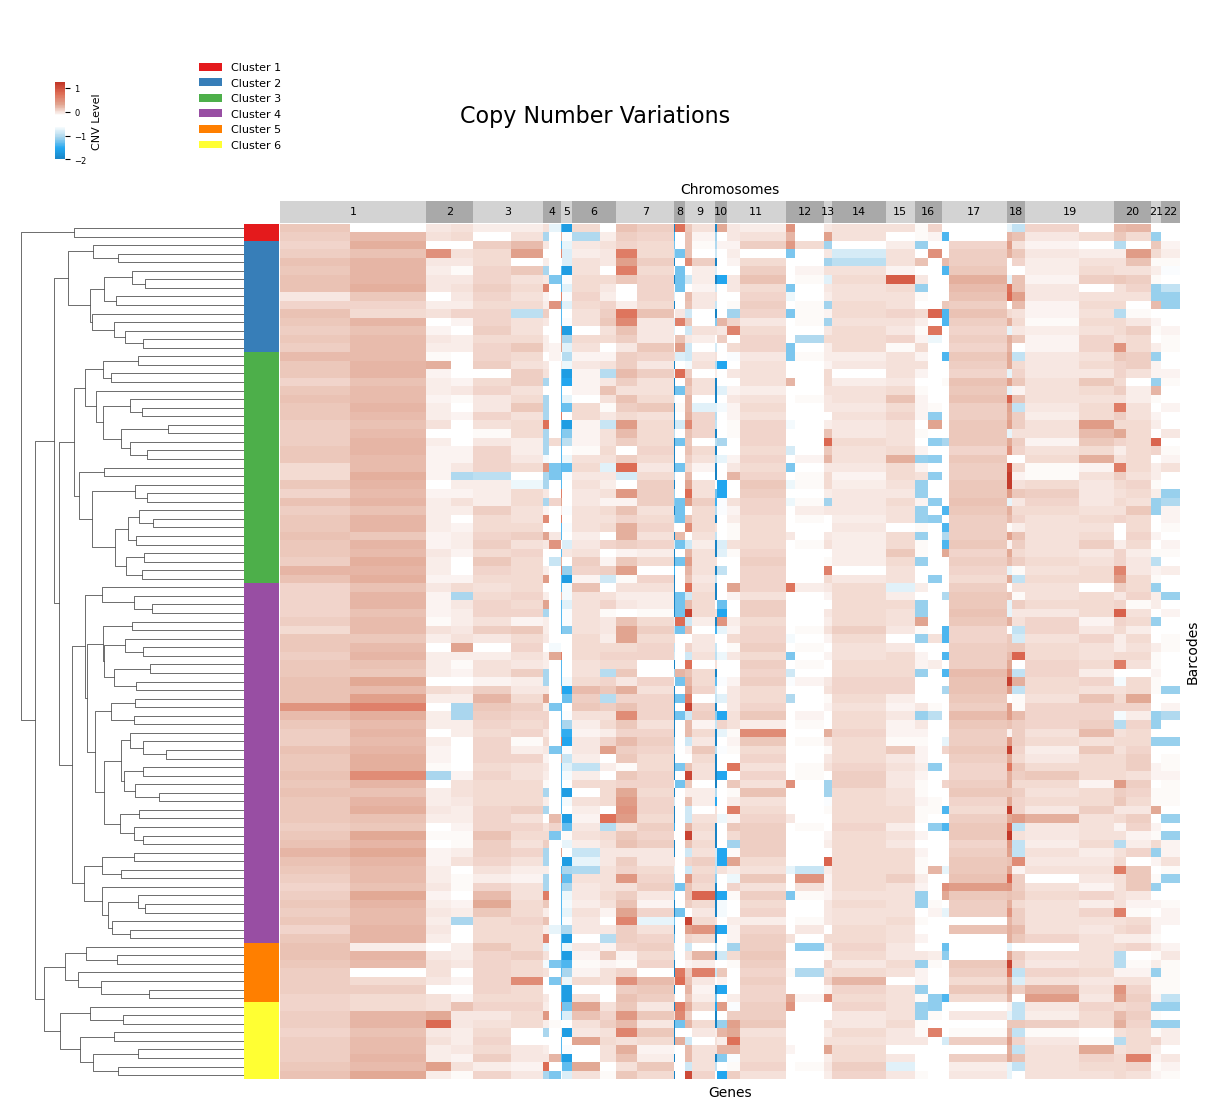

In [43]:

import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch 
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

labelCdt = clusterSortedcnv.iloc[:,0:2]
cnv_matrix = clusterSortedcnv.drop(['CLID', 'NAME'], axis=1)


# 3. Set dendrogram cluster color
method1="canberra"
method2="complete"
ncluster = 6
cnv_matrix_T = cnv_matrix.transpose()
cnv_matrix_T = cnv_matrix_T.iloc[:100,]
dist_matrix = pdist(cnv_matrix_T, metric=method1)
cluster_row = sch.linkage(dist_matrix, method=method2)

# Extract cluster assignments (cutree equivalent)
gr_row = sch.fcluster(cluster_row, t=ncluster, criterion='maxclust')


# 2. Define custom colormap
colors = ["#1984c5", "#22a7f0", "#a7d5ed", "white", "white", "#e1a692", "#de6e56", "#c23728"]
my_cmap = LinearSegmentedColormap.from_list('custom_cnv', colors, N=101)

# 3. Set dendrogram cluster color (for sample clustering/row colors)
method1='canberra'
method2='complete'
ncluster = 6
# dist_matrix = pdist(data, metric=method1)
# cluster_row = sch.linkage(dist_matrix, method=method2)
# gr_row = sch.fcluster(cluster_row, t=ncluster, criterion='maxclust')
col1 = sns.color_palette("Set1", ncluster)
row_colors_list = pd.Series(gr_row).map(lambda x: col1[x-1]).tolist()

# 3. --- Generate Heatmap with integrated Chromosome Bar Plot ---

# clustermap returns a figure grid object
g = sns.clustermap(
    cnv_matrix_T,
    method=method2,
    metric=method1,
    cmap=my_cmap,
    col_cluster=False, # Disable column clustering
    row_colors=row_colors_list,
    cbar_kws={'label': 'CNV Level'},
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 11), # Increased height slightly to accommodate the new bar plot
    # The crucial step is using `cbar_pos` to make space for the extra axis
    # [left, bottom, width, height] in normalized figure coordinates
    cbar_pos=[0.05, 0.85, 0.008, 0.07] 
)
# To make the text/ticks smaller as well (as suggested previously):
g.ax_cbar.tick_params(labelsize=6) 
g.ax_cbar.yaxis.label.set_size(8)
# 4. --- Add the Chromosome Bar Plot using the clustermap's GridSpec ---

# Define colors for alternating chromosome bands
COLOR_LIGHT_GREY = '#D3D3D3'
COLOR_DARK_GREY = '#A9A9A9'
TWO_COLORS = [COLOR_LIGHT_GREY, COLOR_DARK_GREY]

# Calculate bar positions
y1 = chr_meta['count'].values
chromosome_labels = chr_meta['chr'].values
x_bottoms = np.cumsum(y1) - y1
total_width = np.sum(y1) # Total width of the X axis

# Get the existing heatmap axis
ax_heatmap = g.ax_heatmap

# Create a new axis aligned *above* the heatmap axis within the same figure
# We use the internal gridspec 'gs' to manage positioning
# This creates a thin axis that spans the width of the main heatmap (gs[0,2])
# We manually define the position based on the heatmap boundaries
ax_chr_bar_pos = ax_heatmap.get_position()
# Define a new rectangle for the chr bar plot above the heatmap, 0.5 inches tall (approx 0.04 normalized height)
new_bottom = ax_chr_bar_pos.y1 + 0.001 # Place slightly above the main plot
height = 0.02
ax_chr_bar = g.fig.add_axes([ax_chr_bar_pos.x0, new_bottom, ax_chr_bar_pos.width, height])


# Plot the alternating chromosome segments
for i, value in enumerate(y1):
    segment_color = TWO_COLORS[i % 2] 
    ax_chr_bar.bar(
        x=x_bottoms[i],      # Use bottom as X start position for a horizontal bar
        height=1.0,          # Full height of the thin axis
        width=value,         # Width is the 'count' (number of genes)
        bottom=0.0,          # Start at the bottom of the axis
        color=segment_color,
        edgecolor='none',
        align='edge'         # Align by the edge
    )
    # --- Add the Chromosome Label inside the bar ---
    center_x = x_bottoms[i] + (value / 2)
    label_text = str(chromosome_labels[i]) # Get the label from your meta dataframe
    
    ax_chr_bar.text(
        x=center_x,             # X position: Center of the bar (0.5)
        y=0.5,        # Y position: Center of the current segment
        s=label_text,      # The label itself (e.g., '1', '2', '3')
        ha='center',       # Horizontal alignment: Centered
        va='center',       # Vertical alignment: Centered
        fontsize=8,        # Adjust font size as needed
        color='black'      # Set text color to black for visibility
    )

# Clean up the chromosome axis appearance
ax_chr_bar.set_xlim(0, total_width)
ax_chr_bar.set_ylim(0, 1)
ax_chr_bar.set_xticks([]) # Center the ticks in the bar segments
#ax_chr_bar.set_xticklabels(chromosome_labels, rotation=0, fontsize=8)
ax_chr_bar.set_yticks([]) # Hide Y-axis ticks/labels
ax_chr_bar.spines['top'].set_visible(False)
ax_chr_bar.spines['bottom'].set_visible(False)
ax_chr_bar.spines['right'].set_visible(False)
ax_chr_bar.spines['left'].set_visible(False)
ax_chr_bar.set_title("Chromosomes", fontsize=10, pad=5)


# 5. --- Final Adjustments and Saving ---
g.fig.suptitle("Copy Number Variations", fontsize=16, y=0.9)
g.ax_heatmap.set_title("")
g.ax_heatmap.set_ylabel("Barcodes")
g.ax_heatmap.set_xlabel("Genes")

# Add the legend manually to the main heatmap axis
for label in range(1, ncluster + 1):
    g.ax_heatmap.bar(0, 0, color=col1[label-1], label=f'Cluster {label}', linewidth=0)
# Adjust legend position to avoid overlapping the new chromosome plot
g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(-0.1, 1.2), frameon=False, fontsize=8)


# Save the figure
output_file_name = "CNVs_clustered_heatmap_with_dendrogram_and_chrbar.pdf"
g.savefig(output_file_name, bbox_inches='tight')
print(f"Saved figure to {output_file_name}")
plt.show()

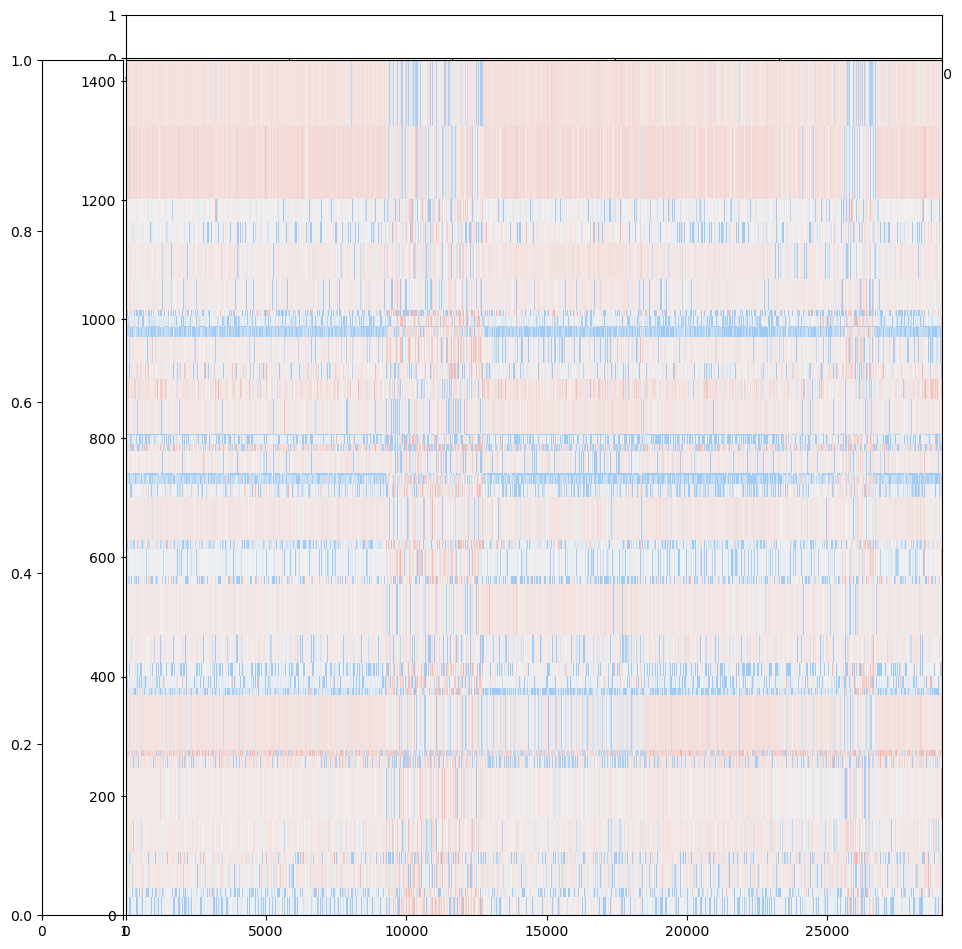

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

# Set vmin and vmax for a data-driven color scale
vmin_val = np.min(df5.values)
vmax_val = np.max(df5.values)
center_val = 0.0

myCol = sns.diverging_palette(
    h_neg=240,  # Blue hues
    h_pos=20,   # Red/Orange hues
    l=80,       # Lightness: 70 is light/muted, 50 is default
    s=80,       # Saturation
    center='light', # Ensure white center
    as_cmap=True
)
# If you are using Matplotlib's pcolormesh or imshow directly, use this:
norm = Normalize(vmin=-1, vmax=0.8)

######### Now plot
# Create a new blank figure object - the overall container for all plots
fig = plt.figure(figsize=(10, 10))

# Creates the grid layout manager. 2,2-specifies a 2-row by 2-col grid; 
gs = GridSpec(2, 2, figure=fig, width_ratios=[0.2, 2], height_ratios=[0.1, 2],
              hspace=0.005, wspace=0.005) # hspace; wspace -- space between plots horizontally and vertically
# Define axes:
ax_empty = fig.add_subplot(gs[0, 0])      # Top Left (Empty)
ax_cluster = fig.add_subplot(gs[0, 1])    # Top Right (Cluster Plot)
ax_chr_bar = fig.add_subplot(gs[1, 0])    # Bottom Left (Chromosome Barplot)
ax_cnv_image = fig.add_subplot(gs[1, 1])  # Bottom Right (Main CNV Heatmap)
# Hide the empty axis
ax_empty.axis('off')

# plot cnv heatmap first
ax_cnv_image.imshow(df6, cmap=myCol, norm=norm, aspect='auto', origin='lower', interpolation='nearest')

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.show()




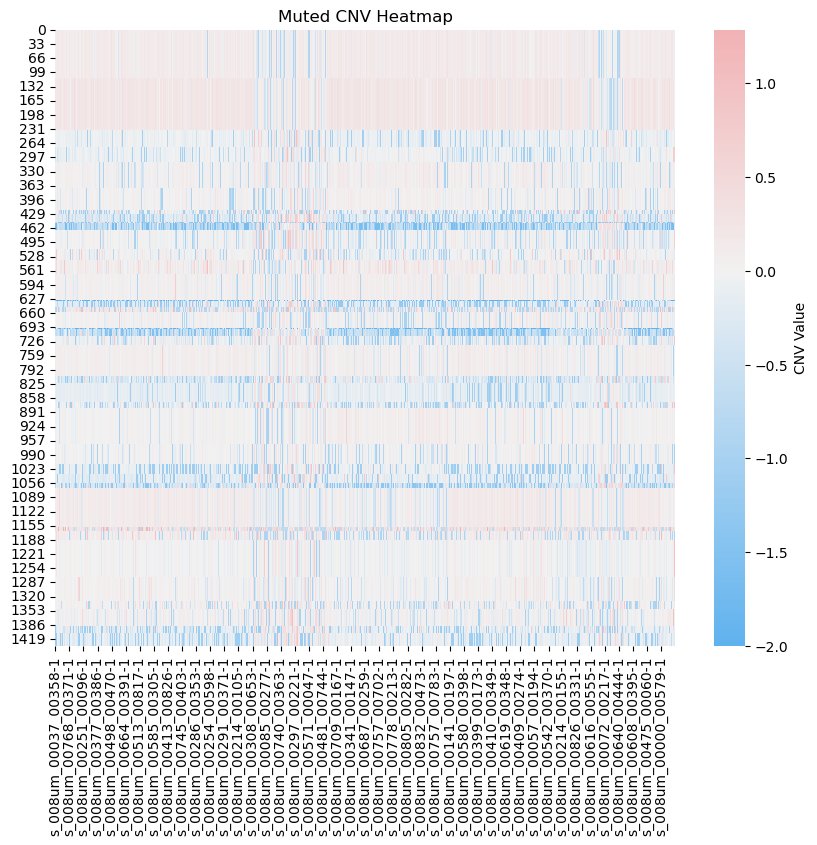

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns # Seaborn heatmaps are generally easier to manage

# --- 1. Evaluate Data Distribution and Determine Breaks ---
# The best practice for divergent data (CNV gain/loss around 0)
# is to set the color limits (vmin, vmax) symmetrically around the center (0).

# Calculate the maximum absolute value in the entire dataset
# Set vmin and vmax for a data-driven color scale
vmin_val = np.min(df5.values)
vmax_val = np.max(df5.values)
center_val = 0.0

# --- 2. Set a Muted Color Scheme ---
# Use a built-in seaborn or matplotlib palette that is inherently less saturated.
# The 'vlag' colormap is a good, muted, divergent choice.
# Other options: 'icefire', or a manually generated sns.diverging_palette(h_neg=240, h_pos=10, l=75, s=80, as_cmap=True)

myCol_muted = sns.diverging_palette(
    h_neg=240,  # Blue hues
    h_pos=10,   # Red/Orange hues
    l=70,       # Lightness: 70 is light/muted, 50 is default
    s=80,       # Saturation
    center='light', # Ensure white center
    as_cmap=True
)

# --- 3. Apply the Normalization ---
# If you are using Matplotlib's pcolormesh or imshow directly, use this:
norm = Normalize(vmin=vmin_val, vmax=vmax_val)

# If you are using Seaborn's heatmap, you pass the values directly:
# sns.heatmap(df5, cmap=myCol_muted, vmin=vmin_val, vmax=vmax_val, center=center_val)

# Example Plotting using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(df5, 
            cmap=myCol_muted, 
            vmin=vmin_val, 
            vmax=vmax_val, 
            center=center_val, 
            cbar_kws={'label': 'CNV Value'})
plt.title("Muted CNV Heatmap")
plt.show()

In [ ]:


class Visualization:

    def cnv_heatmap_withbulkcnv():
        pass


class OrchestratorWorkflow():
    pass
